In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import pickle
import deepRD.tools.trajectoryTools as trajectoryTools
import csv
import math
from deepRD.noiseSampler import noiseSampler
from torchvision.transforms import ToTensor
from torch import nn
from torch.utils.data import DataLoader
from sklearn.neighbors import KernelDensity
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from scipy.stats import wasserstein_distance_nd

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [3]:
# System type: 'bistable', 'dimer'
systemType = 'bistable'

# Conditioning variables: piri, piririm, pipimri, etc. - for dimer, piridqi
conditionedOn = 'piri'

# datapoint = [time (1), qi (3), vi (3), ? (1), ri(3)] -- 11 dim for benchmark
# for dimer, alternating between particle 1 and particle 2.

#for generated trajs, 
# datapoint = [time (1), qi (3), vi (3), ri(3)] - 10 dim

# Datasets directory
localDirectoryBase = "/group/ag_cmb/scratch/maojrs/stochasticClosure/" + systemType + "/boxsize5/"

# loading multiple simulation folders for comparisons, and corresponding labels

datasetFolders = ["benchmarkReducedGen1_piri/", "benchmarkReducedGen0_piri/", "benchmarkReducedGen_piri/"]
datasetLabels = ["model 1", "model 2", "model 3"]
nModels = len(datasetFolders)

nTrajs = 100 # no. of trajectories to load per data folder

nTimestepsBench = 10000 # length of benchmark trajectory
nTimesteps = 200000 # length of coarse-grained trajectory
datapointDim = 10 # dimensionality of datapoints.
numFilesBench = 2500
numFiles = 100 # total no. of files in data folder

#mean_d = torch.tensor([ 4.9998e+02, -1.6760e-02,  3.3266e-03, -1.7140e-03, -1.2232e-05, 
#                        -7.2127e-05,  6.9702e-05, 2.0080e-07,  6.3679e-06, -2.9733e-06])
#std_d = torch.tensor([1.4434e+02, 1.3641e+00, 7.3784e-01, 7.3927e-01, 1.4253e-01, 1.4252e-01, 
#                    1.4256e-01, 1.6200e-02, 1.6212e-02, 1.6207e-02])

# Initialising tensor to store trajectories
dataset = torch.empty((nModels, nTrajs, nTimesteps, datapointDim))
    
# Loading reduced models data

truncate = False # if True, will select random fragment of trajectory

for i, datasetFolder in enumerate(datasetFolders):
    
    filePath = localDirectoryBase + datasetFolder + "simMoriZwanzigReduced_"    
    
    fileIDS = np.sort(np.random.choice(numFiles, nTrajs, replace=False))
    if i==1:
        print(fileIDS)
    
    for j, fnum in enumerate(fileIDS):
        try:
            ds = torch.Tensor(trajectoryTools.loadTrajectory(filePath, fnum))
        except FileNotFoundError:
            print(f'File {fnum} not available')
            continue
            
        dataset[i, j] = ds

#dataset_norm = (dataset[0] - mean_d)/std_d
dataset.shape # nModels, nTrajs, nTimesteps, datapointDims

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]


torch.Size([3, 100, 200000, 10])

In [4]:
# Loading Benchmark data

benchDataset = torch.empty((nTrajs, nTimestepsBench, datapointDim))

fileIDS = np.sort(np.random.choice(numFilesBench, nTrajs, replace=False))

benchFileDirectory = localDirectoryBase + "benchmark/simMoriZwanzig_"

for j, fnum in enumerate(fileIDS):
    try:
        ds = torch.Tensor(trajectoryTools.loadTrajectory(benchFileDirectory, fnum))
    except FileNotFoundError:
        print(f'File {fnum} not available')
        continue

    # cutting out meaningless variable
    if ds.shape[1]==11:
        ds = torch.cat((ds[:, :7], ds[:, -3:]), dim=1)
    
    benchDataset[j] = ds
    
benchDataset.shape

torch.Size([100, 10000, 10])

In [5]:
b_timesteps = benchDataset[:, :, 0]
b_qT = benchDataset[:, :, 1:4]
b_rAuxT = benchDataset[:, :, -3:]
b_rNxtT = torch.roll(b_rAuxT, -1, 1)
b_vT = benchDataset[:, :, 4:7]

timesteps = dataset[:, :, :, 0]
qT = dataset[:, :, :, 1:4]
rAuxT = dataset[:, :, :, -3:]
rNxtT = torch.roll(rAuxT, -1, 2)
vT = dataset[:, :, :, 4:7]

b_timesteps.shape, b_qT.shape, b_rAuxT.shape, b_rNxtT.shape, b_vT.shape, timesteps.shape, qT.shape, rAuxT.shape, rNxtT.shape, vT.shape

(torch.Size([100, 10000]),
 torch.Size([100, 10000, 3]),
 torch.Size([100, 10000, 3]),
 torch.Size([100, 10000, 3]),
 torch.Size([100, 10000, 3]),
 torch.Size([3, 100, 200000]),
 torch.Size([3, 100, 200000, 3]),
 torch.Size([3, 100, 200000, 3]),
 torch.Size([3, 100, 200000, 3]),
 torch.Size([3, 100, 200000, 3]))

In [6]:
mID = 0 # determine which of the reduced models should be analysed.
# Additional models IDs, or set None to omit
mID_2 = None
mID_3 = None

In [7]:
print('Velocity')

print(f'Mean Bench: \t', torch.mean(b_vT, dim=(0,1)))
print('Mean Reduced 1:\t', torch.mean(vT[mID], dim=(0,1)))
if mID_2 is not None:
    print('Mean Reduced 2:\t', torch.mean(vT[mID_2], dim=(0,1)))
if mID_3 is not None:
    print('Mean Reduced 3:\t', torch.mean(vT[mID_3], dim=(0,1)))


print('\nStd Bench: \t', torch.std(b_vT, dim=(0,1)))
print('Std Reduced 1:\t', torch.std(vT[mID], dim=(0,1)))
if mID_2 is not None:
    print('Std Reduced 2:\t', torch.std(vT[mID_2], dim=(0,1)))
if mID_3 is not None:
    print('Std Reduced 3:\t', torch.std(vT[mID_3], dim=(0,1)))
    
print('\n Auxiliary Var')
print('Mean Bench: \t', torch.mean(b_rAuxT, dim=(0,1)))
print('Mean Reduced:\t', torch.mean(rAuxT[mID], dim=(0,1)))
if mID_2 is not None:
    print('Mean Reduced 2:\t', torch.mean(rAuxT[mID_2], dim=(0,1)))
if mID_3 is not None:
    print('Mean Reduced 3:\t', torch.mean(rAuxT[mID_3], dim=(0,1)))


print('\nStd Bench: \t', torch.std(b_rAuxT, dim=(0,1)))
print('Std Reduced 1:\t', torch.std(rAuxT[mID], dim=(0,1)))
if mID_2 is not None:
    print('Std Reduced 2:\t', torch.std(rAuxT[mID_2], dim=(0,1)))
if mID_3 is not None:
    print('Std Reduced 3:\t', torch.std(rAuxT[mID_3], dim=(0,1)))

Velocity
Mean Bench: 	 tensor([ 0.0002, -0.0007, -0.0003])
Mean Reduced 1:	 tensor([-2.7800e-04,  4.7890e-05, -1.6135e-04])

Std Bench: 	 tensor([0.1428, 0.1425, 0.1433])
Std Reduced 1:	 tensor([0.1513, 0.1502, 0.1502])

 Auxiliary Var
Mean Bench: 	 tensor([-8.4941e-06, -2.9713e-06,  4.2867e-05])
Mean Reduced:	 tensor([-1.6722e-05, -4.6728e-05,  5.3042e-05])

Std Bench: 	 tensor([0.0162, 0.0163, 0.0162])
Std Reduced 1:	 tensor([0.0175, 0.0175, 0.0173])


In [8]:
localModelDirectory = '/home/mi/jakut77/cgr/deepRD/deepRD/noiseSampler/models/'

# Load a pretrained Model or None to initialise random

#loadPretrained = None
loadPretrained = localModelDirectory + 'modelWeights/model_state_' + conditionedOn + '_NB1.pt'

# READING LOSS FILE
losses_sum = []
losses_1 = []
losses_2 = []
losses_val = []

# Name of loss file to read
loss_filename = 'losses_piri_B1.csv'

with open(localModelDirectory+'modelLosses/'+loss_filename, mode ='r') as file:    
       csvFile = csv.reader(file)
       for line in csvFile:
           losses_1.append(float(line[0]))
           losses_2.append(float(line[1]))
           losses_sum.append(float(line[2]))
           losses_val.append(float(line[3]))

losses_val = list(dict.fromkeys(losses_val))
len(losses_sum), len(losses_val)#, len(epoch_losses)

(40, 40)

1.3908433099774026e-05 1.4507045182733765e-05 2.8415477915573074e-05 1.3533807308185707e-05


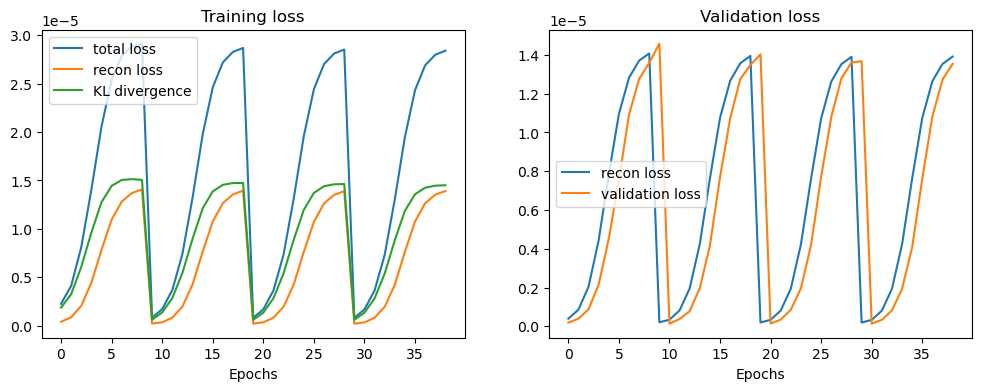

In [9]:
# PLOTTING LOSS
#plt.style.use('fivethirtyeight')

# Cut out first X epochs from the plot
plt_split = 1

fig = plt.figure(figsize=(12,4))

# Plotting the last 100 values for training loss
ax1 = fig.add_subplot(1,2,1)
ax1.plot(losses_sum[plt_split:], label='total loss')
#ax1.plot(losses_sum[:plt_split], label='first 100')
ax1.plot(losses_1[plt_split:], label='recon loss')
ax1.plot(np.array(losses_2[plt_split:]), label='KL divergence')
ax1.set_xlabel('Epochs')
ax1.set_title('Training loss')
ax1.legend()

ax2 = fig.add_subplot(1,2,2)
ax2.plot(losses_1[plt_split:], label='recon loss')
ax2.plot(losses_val[plt_split:], label='validation loss')
#ax2.plot(np.array(epoch_losses[-100:])/20, label='epoch-wise loss')
ax2.set_xlabel('Epochs')
ax2.set_title('Validation loss');
ax2.legend()
print(losses_1[-1], losses_2[-1], losses_sum[-1], losses_val[-1])

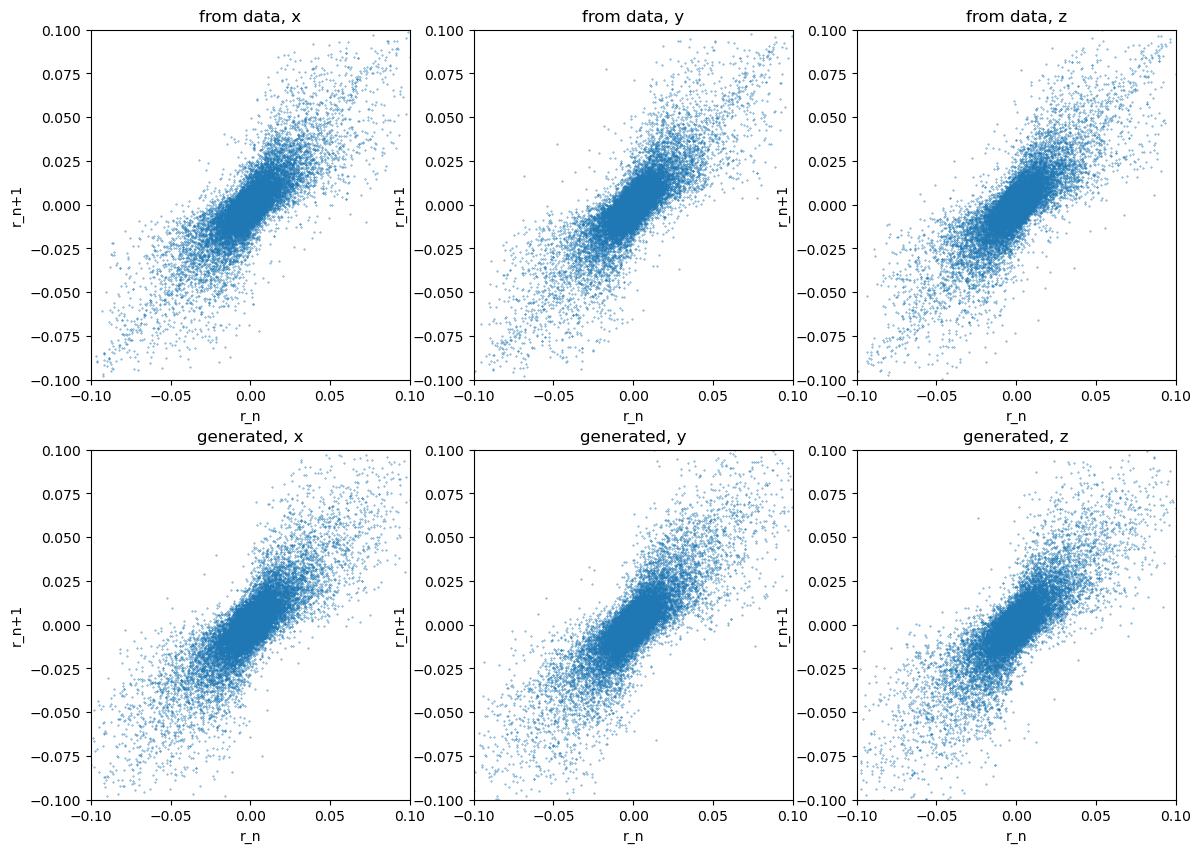

In [12]:
# number of points to plot
nPoints = 30000
b_inds = np.random.choice(nTrajs*nTimestepsBench, nPoints)
inds = np.random.choice(nTrajs*nTimesteps, nPoints)

dim_labels = ['x', 'y', 'z']
dim_index = 2 # choose which dimension to plot
ax_lim = 0.1

# The following plots show the distribution r_n+1 | r_n.

fig = plt.figure(figsize=(14,10))

for i, label in enumerate(dim_labels):
    
    # Benchmark data
    ax = fig.add_subplot(2,3, i+1)
    ax.scatter(b_rAuxT[:, :, i].flatten()[b_inds], b_rNxtT[:, :, i].flatten()[b_inds], s=0.1)
    ax.set_xlabel('r_n')
    ax.set_ylabel('r_n+1')
    ax.set_title(f'from data, {label}')
    ax.set_xlim([-ax_lim,ax_lim])
    ax.set_ylim([-ax_lim,ax_lim])
    
    # Reduced data
    ax2 = fig.add_subplot(2,3, i+4)
    ax2.scatter(rAuxT[mID, :, :, i].flatten()[inds], rNxtT[mID, :, :, i].flatten()[inds], s=0.1)
    ax2.set_xlabel('r_n')
    ax2.set_ylabel('r_n+1')
    ax2.set_title(f'generated, {label}')
    ax2.set_xlim([-ax_lim,ax_lim])
    ax2.set_ylim([-ax_lim,ax_lim])
    
fig.show()

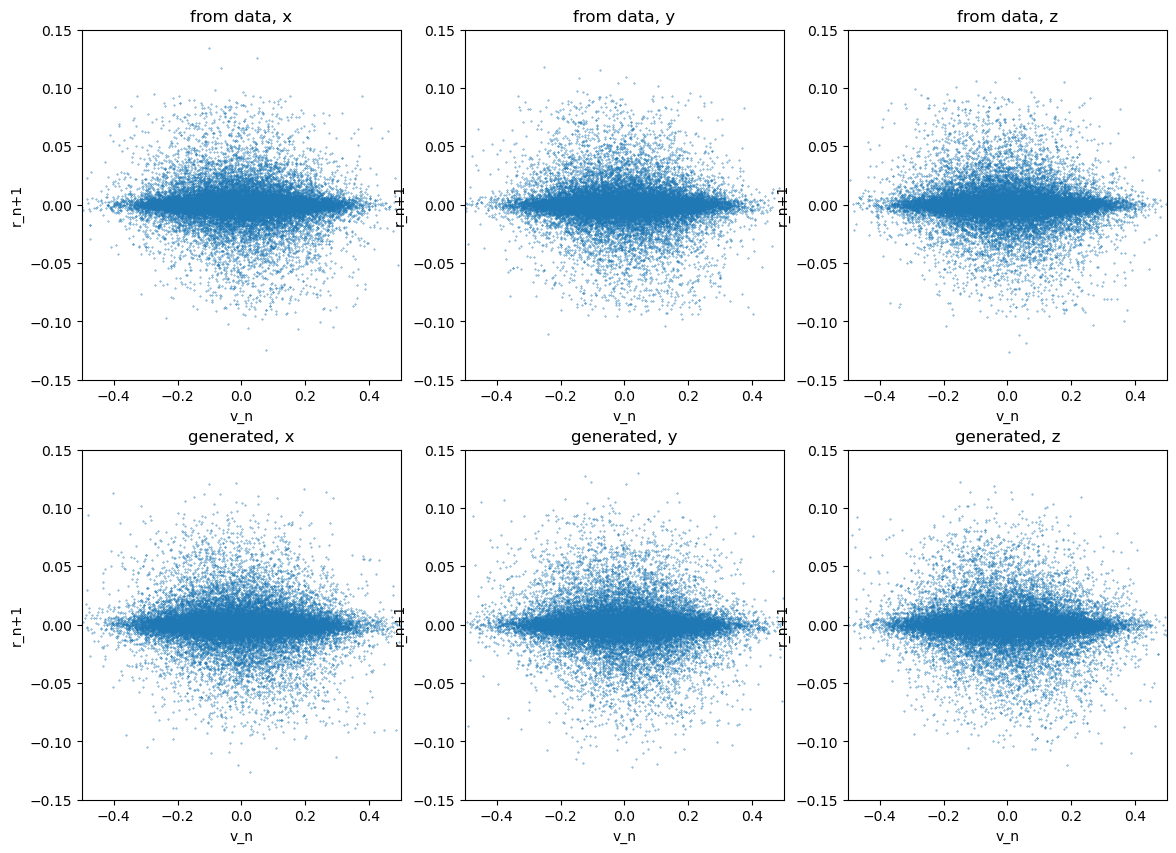

In [13]:
fig = plt.figure(figsize=(14,10))
ax_lim = 0.5
ay_lim = 0.15

for i, label in enumerate(dim_labels):
    
    # Benchmark
    ax = fig.add_subplot(2,3, i+1)
    ax.scatter(b_vT[:, :, i].flatten()[b_inds], b_rNxtT[:, :, i].flatten()[b_inds], s=0.1)
    ax.set_xlabel('v_n')
    ax.set_ylabel('r_n+1')
    ax.set_title(f'from data, {label}')
    ax.set_xlim([-ax_lim,ax_lim])
    ax.set_ylim([-ay_lim,ay_lim])
    
    # Generated
    ax2 = fig.add_subplot(2,3, i+4)
    ax2.scatter(vT[mID, :, :, i].flatten()[inds], rNxtT[mID, :, :, i].flatten()[inds], s=0.1)
    ax2.set_xlabel('v_n')
    ax2.set_ylabel('r_n+1')
    ax2.set_title(f'generated, {label}')
    ax2.set_xlim([-ax_lim,ax_lim])
    ax2.set_ylim([-ay_lim,ay_lim])
    
fig.show()

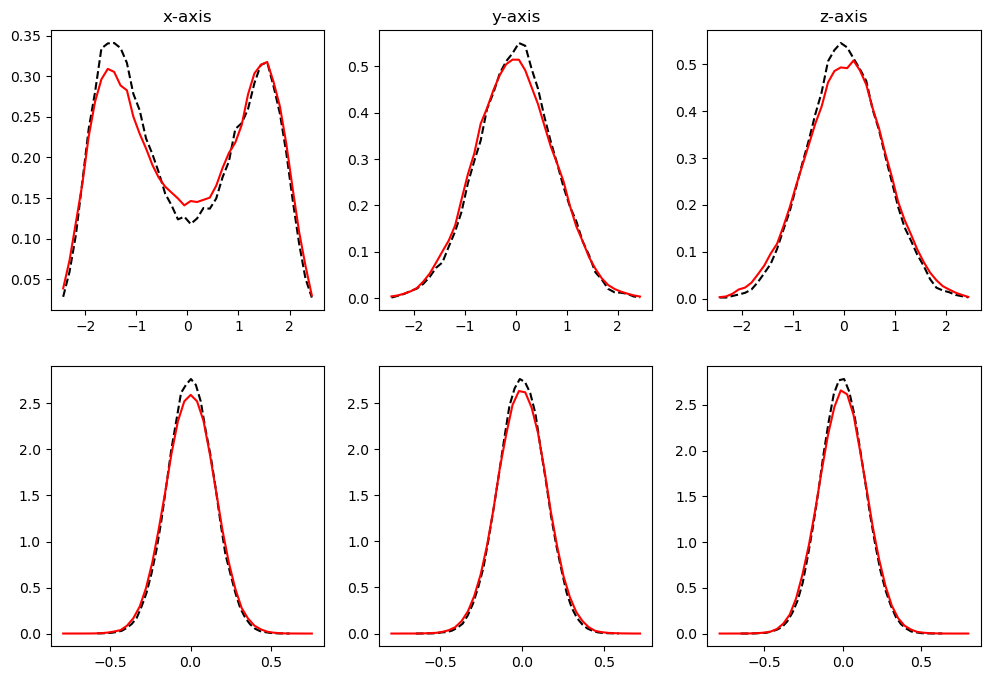

In [14]:
numbins = 40
fig, axes = plt.subplots(2, 3, figsize=(12,8))

for i in range(axes.shape[1]):
    
    ax1, ax2 = axes[:, i]
    
    # Benchmark
    pos1, binEdges1 = np.histogram(b_qT[:, :, i].flatten(), bins=numbins, density=True);
    binsPos1 = 0.5 * (binEdges1[1:] + binEdges1[:-1])
    ax1.plot(binsPos1, pos1,'k--')
    
    pos1, binEdges1 = np.histogram(b_vT[:, :, i].flatten(), bins=numbins, density=True);
    binsPos1 = 0.5 * (binEdges1[1:] + binEdges1[:-1])
    ax2.plot(binsPos1, pos1,'k--')
    
    # Reduced model 1
    pos2, binEdges2 = np.histogram(qT[mID, :, :, i].flatten(), bins=numbins, density=True);
    binsPos2 = 0.5 * (binEdges2[1:] + binEdges2[:-1])
    ax1.plot(binsPos2, pos2, 'r-')
    
    pos2, binEdges2 = np.histogram(vT[mID, :, :, i].flatten(), bins=numbins, density=True);
    binsPos2 = 0.5 * (binEdges2[1:] + binEdges2[:-1])
    ax2.plot(binsPos2, pos2, 'r-')
    
    if mID_2 is not None:
        # Reduced model 2
        pos2, binEdges2 = np.histogram(qT[mID_2, :, :, i].flatten(), bins=numbins, density=True);
        binsPos2 = 0.5 * (binEdges2[1:] + binEdges2[:-1])
        ax1.plot(binsPos2, pos2)
    
        pos2, binEdges2 = np.histogram(vT[mID_2, :, :, i].flatten(), bins=numbins, density=True);
        binsPos2 = 0.5 * (binEdges2[1:] + binEdges2[:-1])
        ax2.plot(binsPos2, pos2)
        
    if mID_3 is not None:
        # Reduced model 2
        pos2, binEdges2 = np.histogram(qT[mID_3, :, :, i].flatten(), bins=numbins, density=True);
        binsPos2 = 0.5 * (binEdges2[1:] + binEdges2[:-1])
        ax1.plot(binsPos2, pos2)
    
        pos2, binEdges2 = np.histogram(vT[mID_3, :, :, i].flatten(), bins=numbins, density=True);
        binsPos2 = 0.5 * (binEdges2[1:] + binEdges2[:-1])
        ax2.plot(binsPos2, pos2)
    
    ax1.set_title(f'{dim_labels[i]}-axis')

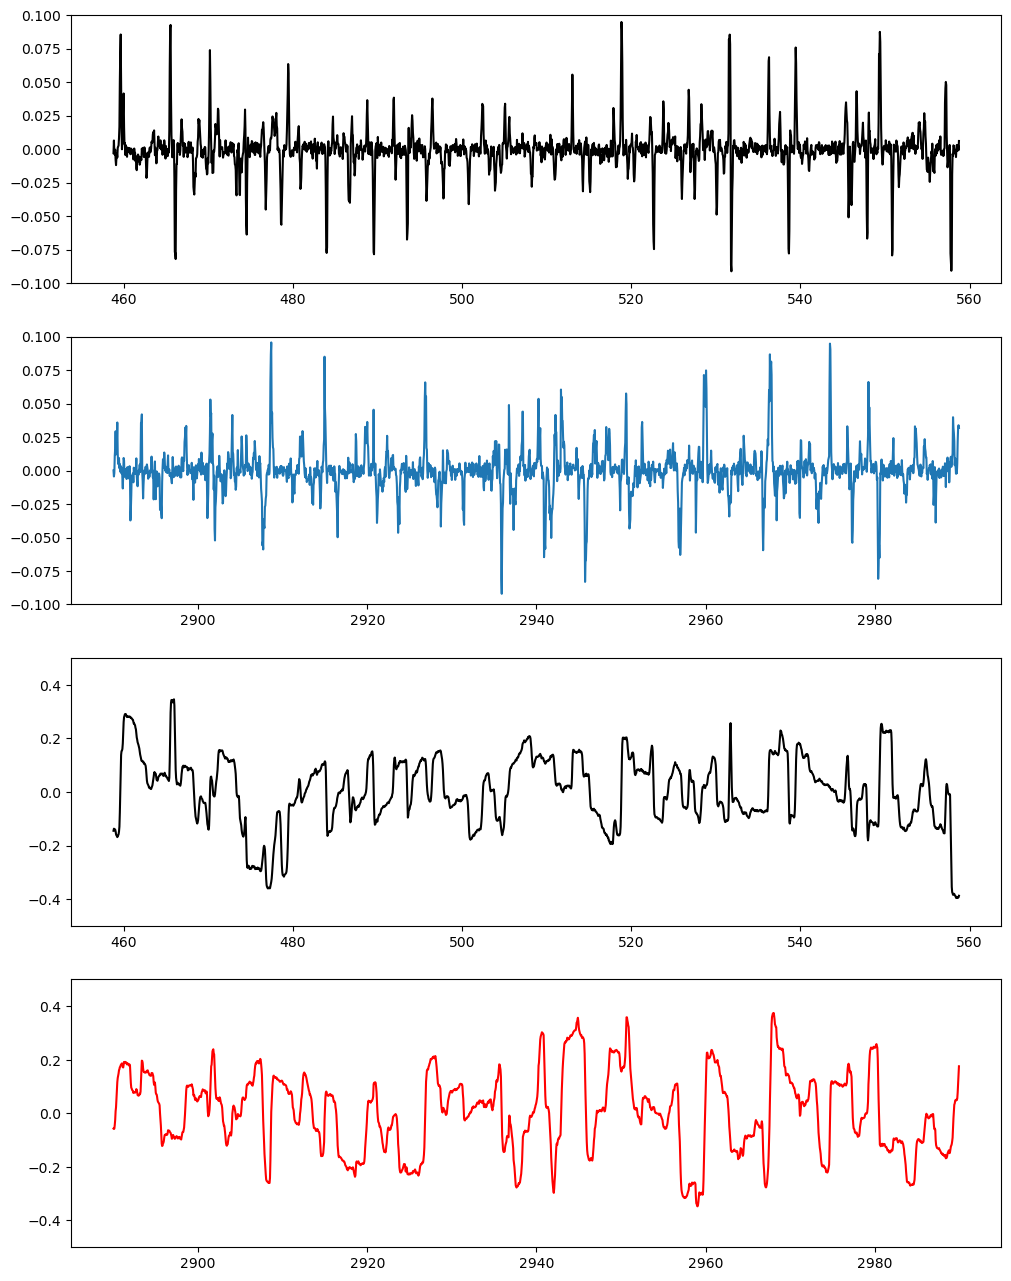

In [15]:
# Plotting R_AUX and V along the trajectory.

plotlength = 2000

x = np.random.randint(nTrajs) # selecting random trajectory.
b_t = b_timesteps[x, :]
t = timesteps[0, x, :]

b_randind = np.random.choice(len(b_t)-2*plotlength)
randind = np.random.choice(len(t)-2*plotlength)
b_endind = b_randind+plotlength
endind = randind+plotlength

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4,1, figsize=(12,16))

# Benchmark
ax1.plot(b_t[b_randind:b_endind], b_rAuxT[x, b_randind:b_endind, 0], 'k')
ax1.set_ylim([-0.1, 0.1])
ax3.plot(b_t[b_randind:b_endind], b_vT[x, b_randind:b_endind, 0], 'k')
ax3.set_ylim([-0.5, 0.5])

# Reduced model
ax2.plot(t[randind:endind], rAuxT[0, x, randind:endind, 0])
ax2.set_ylim([-0.1, 0.1])
ax4.plot(t[randind:endind], vT[0, x, randind:endind, 0], 'r')
ax4.set_ylim([-0.5, 0.5])

fig.show()

In [17]:
#Calculating the Mean Squared Displacement of the particle.
b_rT = torch.norm(b_qT, dim=-1)
b_diffsq = torch.diff(b_rT, dim=-1)**2
b_MSD = torch.mean(b_diffsq)

rT = torch.norm(qT, dim=-1)
diffsq = torch.diff(rT, dim=-1)**2
MSD = torch.mean(diffsq, dim=(1,2))

print('Mean Square Displacement:')
print('Benchmark:', float(b_MSD))
print('Model 1:', float(MSD[0]))
print('Model 2:', float(MSD[1]))
print('Model 3:', float(MSD[2]))

Mean Square Displacement:
Benchmark: 5.104573938297108e-05
Model 1: 5.660070382873528e-05
Model 2: 5.3942178055876866e-05
Model 3: 5.366444747778587e-05


(2, 10)


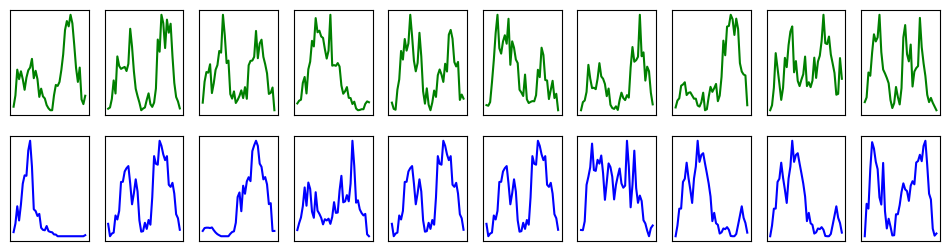

In [18]:
# Truncating
truncate = True

if truncate==True:
            
    sind = np.random.randint(4999, 190000) # starting ind for full-time trajectories
    eind = sind + nTimestepsBench

else:
    sind = 0
    eind = 200000

fig, axes = plt.subplots(2, 10, figsize=(12,3))
print(axes.shape)

trajInds = np.sort(np.random.choice(nTrajs, 10, replace=False))

for i, ind in enumerate(trajInds):
    
    # Benchmark
    pos, binEdges = np.histogram(b_qT[ind, :, 0], bins=numbins, density=True);
    binsPos = 0.5 * (binEdges[1:] + binEdges[:-1])
    axes[0, i].plot(binsPos, pos, c='g')
    
    # Reduced model
    pos, binEdges = np.histogram(qT[0, ind, sind:eind, 0], bins=numbins, density=True);
    binsPos = 0.5 * (binEdges[1:] + binEdges[:-1])
    axes[1, i].plot(binsPos, pos, c='b')
    
    axes[0, i].axes.get_xaxis().set_ticks([])
    axes[0, i].axes.get_yaxis().set_ticks([])
    axes[1, i].axes.get_xaxis().set_ticks([])
    axes[1, i].axes.get_yaxis().set_ticks([])

benchmark


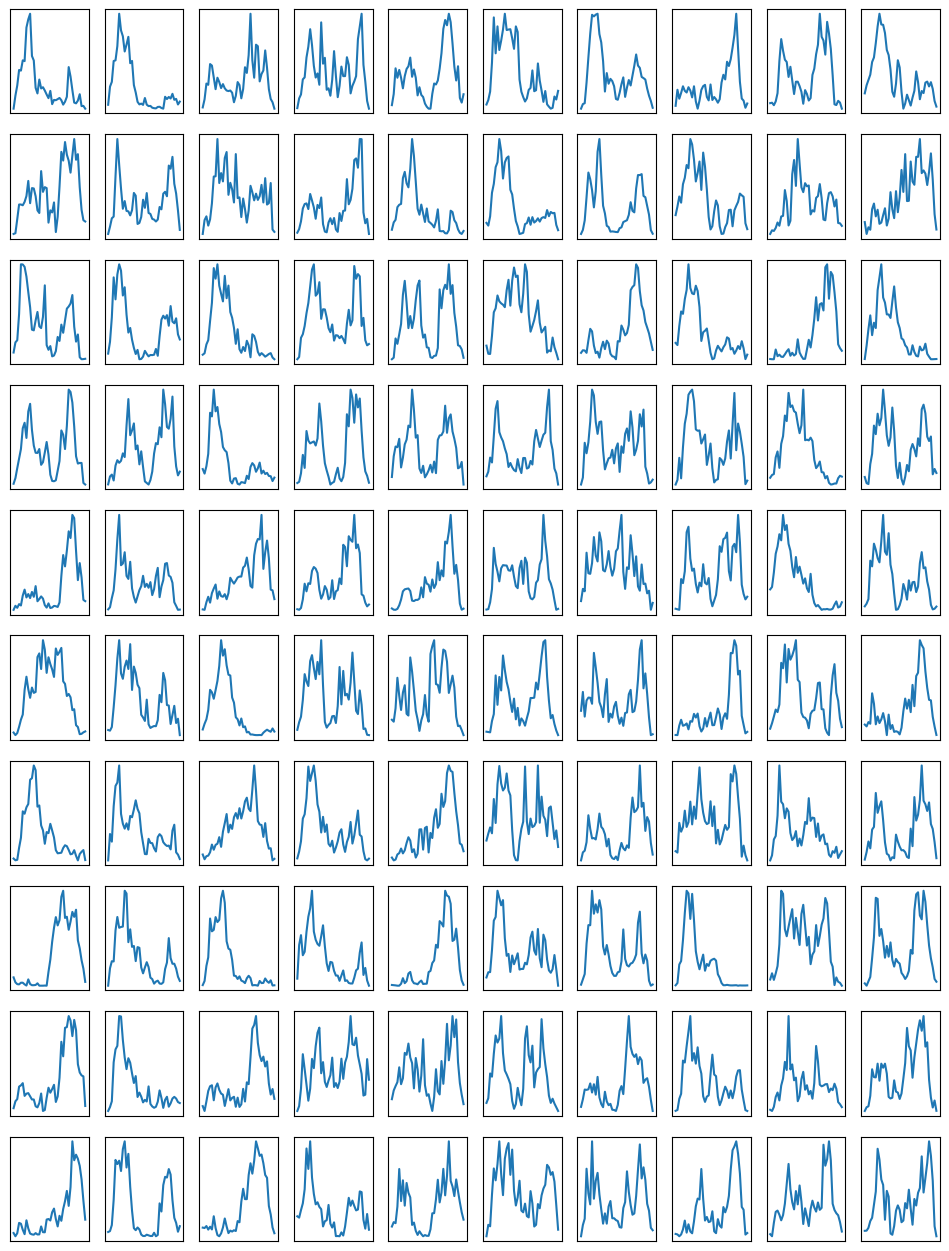

In [19]:
# BENCHMARK

fig = plt.figure(figsize=(12,16))

for i in range(nTrajs):
    
    pos, binEdges = np.histogram(b_qT[i, :, 0], bins=numbins, density=True);
    binsPos = 0.5 * (binEdges[1:] + binEdges[:-1])
    ax = fig.add_subplot(10, 10, i+1)
    ax.plot(binsPos, pos)
    ax.axes.get_xaxis().set_ticks([])
    ax.axes.get_yaxis().set_ticks([])

print("benchmark")
fig.show()

reduced model


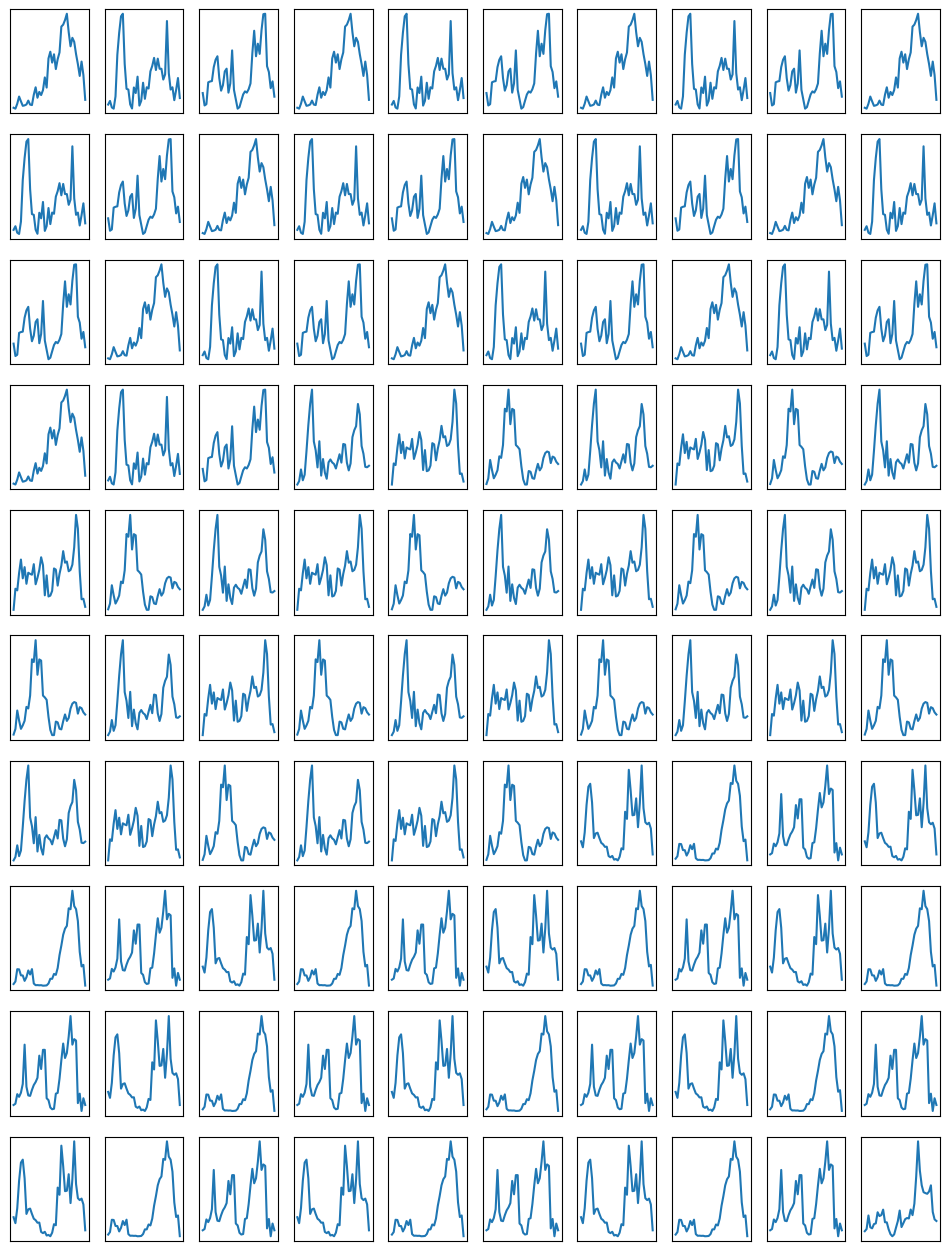

In [20]:
# REDUCED MODEL

fig = plt.figure(figsize=(12,16))

for i in range(nTrajs):
    
    pos, binEdges = np.histogram(qT[1, i, sind:eind, 0], bins=numbins, density=True);
    binsPos = 0.5 * (binEdges[1:] + binEdges[:-1])
    ax = fig.add_subplot(10, 10, i+1)
    ax.plot(binsPos, pos)
    ax.axes.get_xaxis().set_ticks([])
    ax.axes.get_yaxis().set_ticks([])

print("reduced model")
fig.show()

In [21]:
# CALCULATING AUTOCORRELATION FUNCTIONS.
print(sind, eind)
lagtimesteps = 2000
mTrajs = 20

def correlation_fft(a, b, trunc):
    """Calculates correlation via FFT."""
    len_a = len(a)
    a = np.concatenate([a, np.zeros(len_a)])
    b = np.concatenate([b, np.zeros(len_a)])
    a_fft = np.fft.fft(a)
    b_fft = np.fft.fft(b)
    corr = np.fft.ifft(a_fft * np.conj(b_fft))
    corr = corr[:trunc].real
    corr /= np.linspace(len_a, len_a - trunc + 1, trunc)
    return corr

123491 133491


In [38]:
# MAURICIO ACF FUNCTION

ACF_M = np.zeros((2, 2, lagtimesteps))

print('Benchmark \n')
# position
ACF_M[0, 0] = trajectoryTools.calculateAutoCorrelationFunction(np.array(benchDataset[np.random.choice(nTrajs, mTrajs, replace=False)]), lagtimesteps, var='position')
# velocity
ACF_M[0, 1] = trajectoryTools.calculateAutoCorrelationFunction(np.array(benchDataset[np.random.choice(nTrajs, mTrajs, replace=False)]), lagtimesteps, var='velocity')

print('Reduced')
# position
ACF_M[1, 0] = trajectoryTools.calculateAutoCorrelationFunction(np.array(dataset[0, np.random.choice(nTrajs, mTrajs, replace=False), sind:eind]), lagtimesteps, var='position')
# velocity
ACF_M[1, 1] = trajectoryTools.calculateAutoCorrelationFunction(np.array(dataset[0, np.random.choice(nTrajs, mTrajs, replace=False), sind:eind]), lagtimesteps, var='velocity')

Benchmark 

Reducedng ACF for velocity :  100.0 % complete   


In [22]:
# ACF by FFT for 1-D traj, then summing up over vector dimensions and all trajs 
ACF_FFT = np.zeros((2, 2, lagtimesteps))
    
for trajInd in np.random.choice(nTrajs, mTrajs):
    
    #print('Benchmark')
    # position
    ACF_FFT[0, 0] += np.sum([correlation_fft(b_qT[trajInd, :, i], b_qT[trajInd, :, i], lagtimesteps) for i in range(b_qT.shape[2])], axis=0)
    # velocity
    ACF_FFT[0, 1] += np.sum([correlation_fft(b_vT[trajInd, :, i], b_vT[trajInd, :, i], lagtimesteps) for i in range(b_vT.shape[2])], axis=0)
    
    #print('Reduced')
    ACF_FFT[1, 0] += np.sum([correlation_fft(qT[0, trajInd, :, i], qT[0, trajInd, :, i], lagtimesteps) for i in range(qT.shape[3])], axis=0)
    ACF_FFT[1, 1] += np.sum([correlation_fft(vT[0, trajInd, :, i], vT[0, trajInd, :, i], lagtimesteps) for i in range(vT.shape[3])], axis=0)
    
    #ACF_FFT[0] += np.sum([correlation_fft(b_vTraj[:, i], b_vTraj[:, i], lagtimesteps) for i in range(b_vTraj.shape[1])], axis=0)
    #ACF_FFT[1] += np.sum([correlation_fft(vTraj[:, i], vTraj[:, i], lagtimesteps) for i in range(vTraj.shape[1])], axis=0)
    
ACF_FFT[0, 0] /= ACF_FFT[0, 0, 0]
ACF_FFT[0, 1] /= ACF_FFT[0, 1, 0]
ACF_FFT[1, 0] /= ACF_FFT[1, 0, 0]
ACF_FFT[1, 1] /= ACF_FFT[1, 1, 0]

<function matplotlib.pyplot.show(close=None, block=None)>

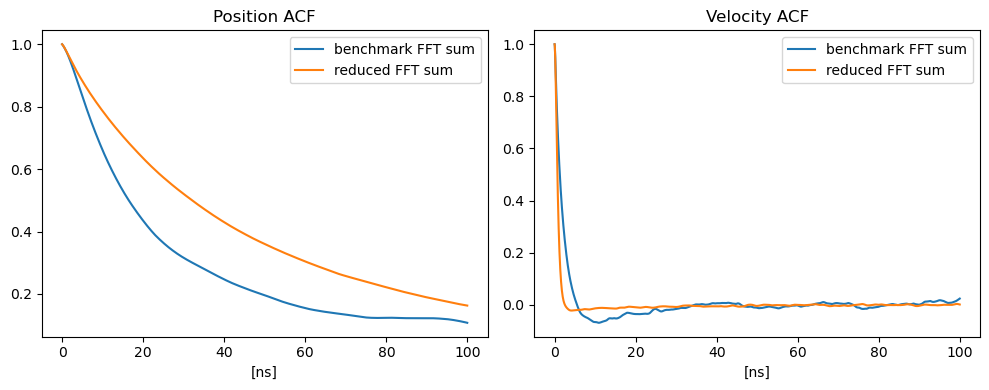

In [23]:
# Plotting comparison for ACFs

# timestep - 0.05 nanoseconds
# 2000 timesteps - 100 ns

time = np.arange(lagtimesteps)*0.05
fig, axes = plt.subplots(1,2, figsize=(10,4))

#axes[0].plot(time, ACF_M[0, 0], label='benchmark M')
axes[0].plot(time, ACF_FFT[0, 0], label='benchmark FFT sum')
#axes[0].plot(time, ACF_M[1, 0], label='reduced M')
axes[0].plot(time, ACF_FFT[1, 0], label='reduced FFT sum')
axes[0].set_title('Position ACF')
axes[0].set_xlabel('[ns]')
axes[0].legend()

#axes[1].plot(time, ACF_M[0, 1], label='benchmark M')
axes[1].plot(time, ACF_FFT[0, 1], label='benchmark FFT sum')
#axes[1].plot(time, ACF_M[1, 1], label='reduced M')
axes[1].plot(time, ACF_FFT[1, 1], label='reduced FFT sum')
axes[1].set_title('Velocity ACF')
axes[1].set_xlabel('[ns]')
axes[1].legend()

plt.tight_layout()
plt.show

In [142]:
# BINNING ON VOXELS

# r_n in [-0.1, 0.1] ; v_n in [-0.5, 0.5]

#print(b_rNxtT.shape, b_vT.shape, b_rAuxT.shape)

# Determine edges of intervals

# r_n in [-0.1, 0.1] ; v_n in [-0.5, 0.5]
print('Velocity Range:')
for i, label in enumerate(dim_labels):
    print(label, ':', float(torch.min(b_vT[:, :, i])), ':', float(torch.max(b_vT[:, :, i])))
    
print('Auxiliary Var Range:')
for i, label in enumerate(dim_labels):
    print(label, ':', float(torch.min(b_rAuxT[:, :, i])), ':', float(torch.max(b_rAuxT[:, :, i])))

# space limits for v and r respectively
limit = [0.6, 0.15]
nBoxes = 20 # number of subfields that the space is divided into PER AXIS (2-d plots will yield nBoxes**2 fields)
boxLength = [2*limit[0]/nBoxes, 2*limit[1]/nBoxes]

# Determine axes to vary r and v: 0 - x, 1 - y, 2 - z axis
v_ax = 0
r_ax = 0


b_voxMeans = torch.zeros((nBoxes, nBoxes, 3))
b_voxStd = torch.zeros((nBoxes, nBoxes, 3))

voxMeans = torch.zeros((nBoxes, nBoxes, 3))
voxStd = torch.zeros((nBoxes, nBoxes, 3))

for i in range(nBoxes):
    for j in range(nBoxes):
        
        v_Int = [-limit[0]+i*boxLength[0], -limit[0]+(i+1)*boxLength[0]]
        r_Int = [-limit[1]+j*boxLength[1], -limit[1]+(j+1)*boxLength[1]]

        mask_v = (b_vT[:, :, v_ax] >= v_Int[0]) & (b_vT[:, :, v_ax] <= v_Int[1])
        mask_r = (b_rAuxT[:, :, r_ax] >= r_Int[0]) & (b_rAuxT[:, :, r_ax] <= r_Int[1])
        mask = mask_v & mask_r

        b_indices = torch.nonzero(mask , as_tuple=True)
        b_voxSamples = b_rNxtT[b_indices]
        
        b_voxMeans[i, j] = torch.mean(b_voxSamples, 0)
        b_voxStd[i, j] = torch.std(b_voxSamples, 0)
        
        mask_v = (vT[mID, :, :, v_ax] >= v_Int[0]) & (vT[mID, :, :, v_ax] <= v_Int[1])
        mask_r = (rAuxT[mID, :, :, r_ax] >= r_Int[0]) & (rAuxT[mID, :, :, r_ax] <= r_Int[1])
        mask = mask_v & mask_r

        indices = torch.nonzero(mask , as_tuple=True)
        voxSamples = rNxtT[mID][indices]
        
        voxMeans[i, j] = torch.mean(voxSamples, 0)
        voxStd[i, j] = torch.std(voxSamples, 0)
                
print(voxMeans[:, :, 0].shape, voxStd.shape)

Velocity Range:
x : -0.6555984616279602 : 0.6100071668624878
y : -0.6118279695510864 : 0.6335051655769348
z : -0.6262171864509583 : 0.6044456958770752
Auxiliary Var Range:
x : -0.15340308845043182 : 0.14682073891162872
y : -0.15421698987483978 : 0.1526489108800888
z : -0.13749317824840546 : 0.15406447649002075


/tmp/ipykernel_2137048/1017125779.py:48: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /croot/pytorch-select_1730848721463/work/aten/src/ATen/native/ReduceOps.cpp:1807.)
  b_voxStd[i, j] = torch.std(b_voxSamples, 0)
/tmp/ipykernel_2137048/1017125779.py:58: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /croot/pytorch-select_1730848721463/work/aten/src/ATen/native/ReduceOps.cpp:1807.)
  voxStd[i, j] = torch.std(voxSamples, 0)


torch.Size([20, 20]) torch.Size([20, 20, 3])


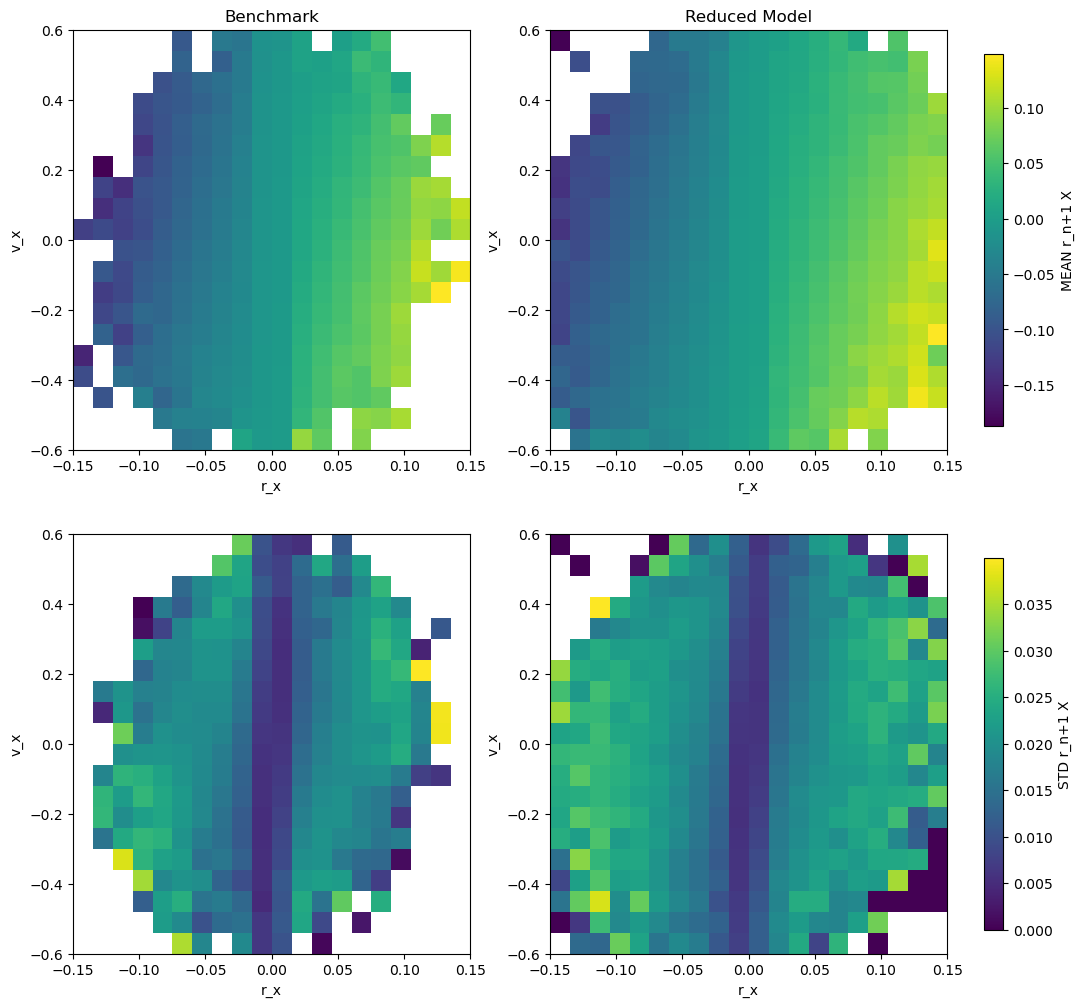

In [143]:
# Dimension to plot: 0 - x, 1 - y, 2 - z
vox_ax = 0

fig, axes = plt.subplots(2, 2, figsize=(12,12))

# Benchmark
im1 = axes[0, 0].imshow(b_voxMeans[:, :, vox_ax], origin='lower', aspect='auto', extent=[-limit[1], limit[1], -limit[0], limit[0]])
im3 = axes[1, 0].imshow(b_voxStd[:, :, vox_ax], origin='lower', aspect='auto', extent=[-limit[1], limit[1], -limit[0], limit[0]])

# Reduced
im1 = axes[0, 1].imshow(voxMeans[:, :, vox_ax], origin='lower', aspect='auto', extent=[-limit[1], limit[1], -limit[0], limit[0]])
im3 = axes[1, 1].imshow(voxStd[:, :, vox_ax], origin='lower', aspect='auto', extent=[-limit[1], limit[1], -limit[0], limit[0]])

axes[0, 0].set_title('Benchmark')
axes[0, 1].set_title('Reduced Model')

for ax in axes.flatten():
    ax.set_ylabel(f'v_{dim_labels[v_ax]}')
    ax.set_xlabel(f'r_{dim_labels[r_ax]}')


fig.colorbar(im1, ax=axes[0], orientation='vertical', fraction=0.02, pad=0.04, label='MEAN r_n+1 X')
fig.colorbar(im3, ax=axes[1], orientation='vertical', fraction=0.02, pad=0.04, label='STD r_n+1 X')
fig.show()

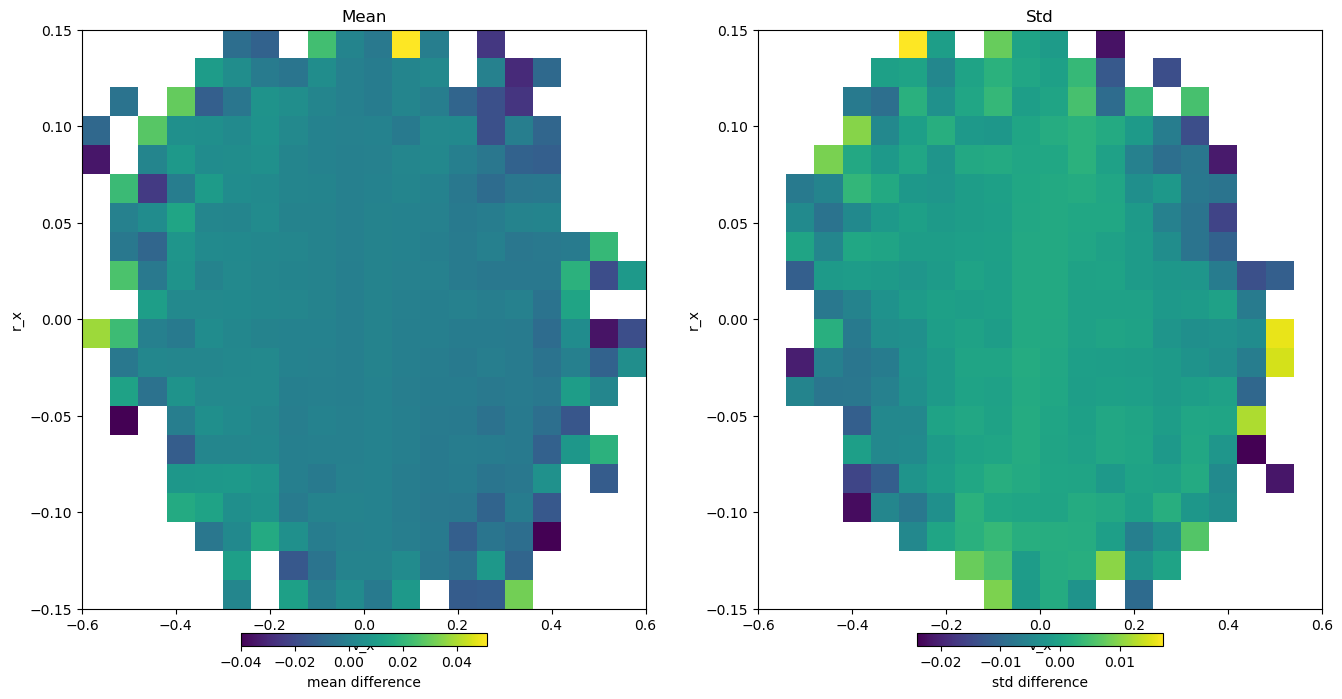

In [144]:
# Plotting the deviation

fig, axes = plt.subplots(1, 2, figsize=(16,8))

# Benchmark
im1 = axes[0].imshow(b_voxMeans[:, :, 0] - voxMeans[:, :, 0], aspect='auto', extent=[-limit[0], limit[0], -limit[1], limit[1]])
im3 = axes[1].imshow(b_voxStd[:, :, 0] - voxStd[:, :, 0], aspect='auto', extent=[-limit[0], limit[0], -limit[1], limit[1]])

axes[0].set_title('Mean')
axes[1].set_title('Std')

for ax in axes.flatten():
    ax.set_xlabel('v_x')
    ax.set_ylabel('r_x')
    
fig.colorbar(im1, ax=axes[0], orientation='horizontal', fraction=0.02, pad=0.04, label='mean difference')
fig.colorbar(im3, ax=axes[1], orientation='horizontal', fraction=0.02, pad=0.04, label='std difference')

fig.show()

In [95]:
b_rNxtT[b_indices].shape, torch.min(b_vT[b_indices][:, 0]), torch.max(b_vT[b_indices][:, 0]), torch.min(b_rAuxT[b_indices][:, 0]), torch.max(b_rAuxT[b_indices][:, 0]) # consistency check
#b_rNxtT[indices].shape

(torch.Size([4, 3]),
 tensor(0.3635),
 tensor(0.4219),
 tensor(0.0915),
 tensor(0.0982))

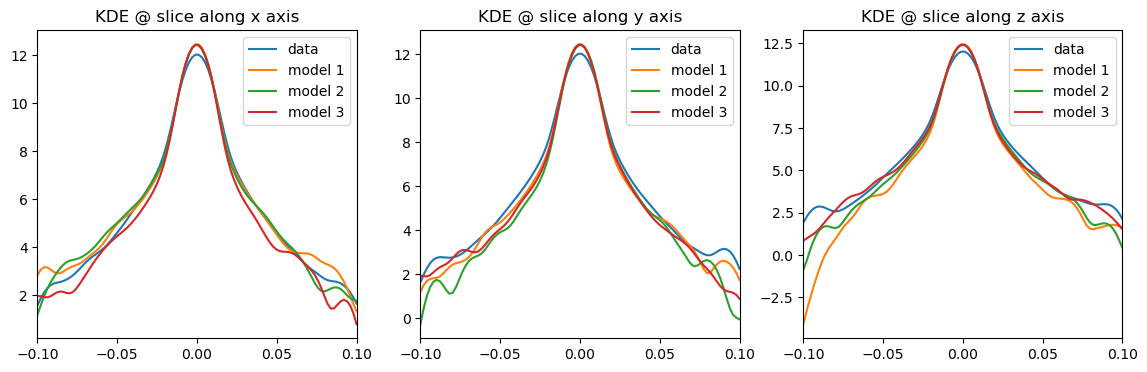

In [21]:
# Kernel Density Estimation - 3-dimensional fit (x,y,z)
axe_lim = 0.1

# Original data
kde1 = KernelDensity(bandwidth=0.005)
kde1.fit(b_rAuxT.flatten(end_dim=1))

# Generated data (reduced model 1)
kde2 = KernelDensity(bandwidth=0.005)
kde2.fit(rAuxT[mID, :, sind:eind].flatten(end_dim=1));

if mID_2 is not None:
    # Second model samples - for comparison
    kde3 = KernelDensity(bandwidth=0.005)
    kde3.fit(rAuxT[mID_2, :, sind:eind].flatten(end_dim=1))
    
if mID_3 is not None:
    # Second model samples - for comparison
    kde4 = KernelDensity(bandwidth=0.005)
    kde4.fit(rAuxT[mID_3, :, sind:eind].flatten(end_dim=1))

# Draw grid
num_gridpts = 100
grid_1d = np.linspace(-axe_lim, axe_lim, num_gridpts)
c_yz = 0.0
E = np.full((num_gridpts,2), c_yz)
grid_slice = np.concatenate((grid_1d[:, np.newaxis], E), axis=1)

fig = plt.figure(figsize=(14,4))

for i, dim in enumerate(dim_labels):
    
    grid_slice = np.insert(E, i, grid_1d, axis=1)

    # Evaluate KDE on grid slice
    pdf_data = kde1.score_samples(grid_slice)
    pdf_gen = kde2.score_samples(grid_slice)
    if mID_2 is not None:
        pdf_gen2 = kde3.score_samples(grid_slice)
    if mID_3 is not None:
        pdf_gen3 = kde4.score_samples(grid_slice)

    # Plotting 3D KDE evaluation at (x, 0, 0)
    ax = fig.add_subplot(1,3,i+1)
    ax.plot(grid_slice[:,i], pdf_data, label='data')
    ax.plot(grid_slice[:,i], pdf_gen, label='model 1')
    if mID_2 is not None:
        ax.plot(grid_slice[:,i], pdf_gen2, label='model 2')
    if mID_3 is not None:
        ax.plot(grid_slice[:,i], pdf_gen3, label='model 3')
    ax.set_title(f'KDE @ slice along {dim} axis')
    ax.set_xlim([-axe_lim, axe_lim])
    ax.legend()
    
fig.show()

In [16]:
z_samples = torch.normal(0, 1.2, (num_samples, self.latentDims))

NameError: name 'num_samples' is not defined

In [15]:
# Estimating mean and cov of latent space distribution
latent_mean = np.mean(np.array(z), axis=0)
latent_cov = np.cov(np.array(z), rowvar=0)
#print(latent_mean, [latent_cov[i, i] for i in range(latentDims)])


# Extracting principal components
pca = PCA(n_components=latentDims)
pca.fit(z)
print('Explained variance distribution:\n', pca.explained_variance_ratio_)

lax = 4
#pts = np.random.choice(inds, 10000)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,8))

ax1.scatter(z[inds, 0], z[inds, 1], s=0.5, alpha=0.5)
circle1 = plt.Circle((0, 0), 2, color='r', fill=False)
ax1.add_patch(circle1)
ax1.set_xlim([-lax, lax])
ax1.set_ylim([-lax, lax])
ax1.set_title('Latent space distribution from test data')

ax2.scatter(z_gen[inds, 0], z_gen[inds, 1], s=0.5, alpha=0.5)
circle1 = plt.Circle((0, 0), VAE.cutoff, color='r', fill=False)
ax2.add_patch(circle1)
ax2.set_xlim([-lax, lax])
ax2.set_ylim([-lax, lax])
ax2.set_title('Generated latent points')

fig.show()

NameError: name 'z' is not defined